In [76]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [77]:
df = pd.read_csv("SalaryData.csv")
df.head(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0
9,38.0,Male,PhD,Senior Scientist,10.0,110000.0


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.7 KB


In [79]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [80]:
df.isna().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [81]:
df.dropna(inplace=True)

In [82]:
df.duplicated().sum()

np.int64(49)

In [83]:
df.drop_duplicates(inplace=True)

In [84]:
df.info()

<class 'pandas.DataFrame'>
Index: 324 entries, 0 to 371
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  324 non-null    float64
 1   Gender               324 non-null    str    
 2   Education Level      324 non-null    str    
 3   Job Title            324 non-null    str    
 4   Years of Experience  324 non-null    float64
 5   Salary               324 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.7 KB


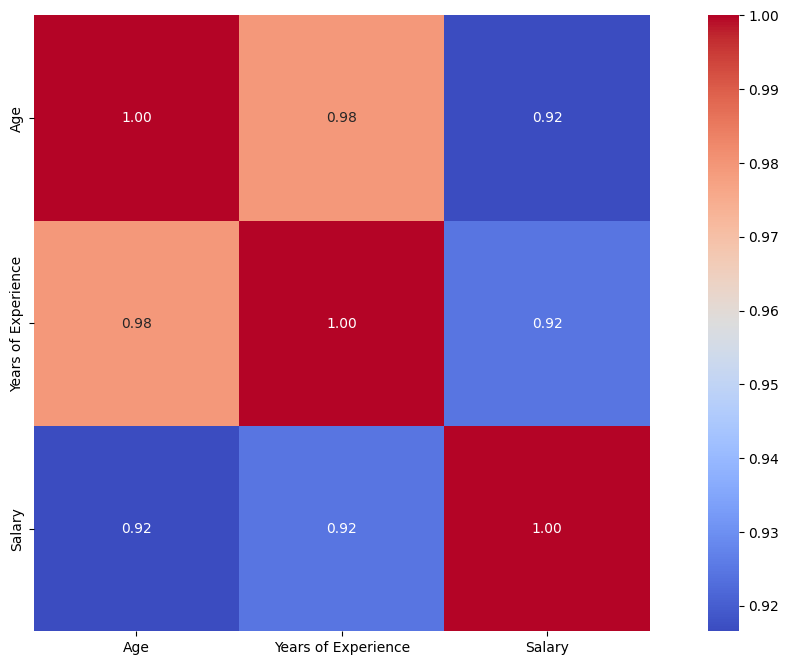

In [85]:
df_numeric = df.select_dtypes(include=["number"])
plt.figure(figsize=(15, 8))
sns.heatmap(df_numeric.corr(), cmap='coolwarm', annot=True, fmt='.2f', square=True)
plt.show()


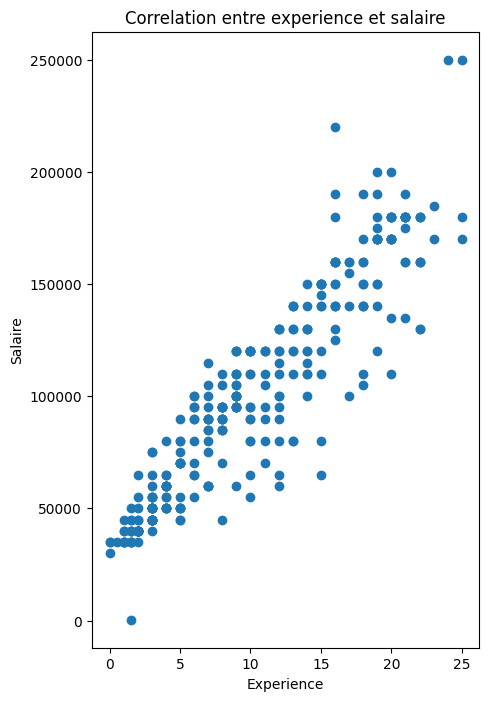

In [86]:
plt.figure(figsize=(5,8))
plt.scatter(df['Years of Experience'], df['Salary'])
plt.xlabel("Experience")
plt.ylabel("Salaire")
plt.title("Correlation entre experience et salaire")
plt.show()

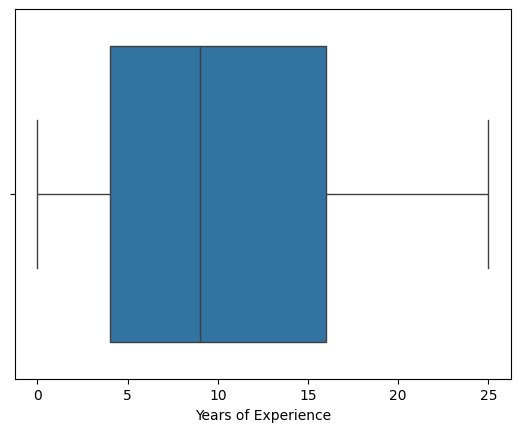

In [87]:
sns.boxplot(x=df['Years of Experience'])
plt.show()

In [88]:
X = df.drop(['Gender', 'Education Level', 'Job Title', 'Salary'], axis=1)

In [89]:
Y = df['Salary']

In [90]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [91]:
X_train

,Age,Years of Experience
274,30.0,2.0
81,41.0,13.0
148,38.0,10.0
39,49.0,21.0
225,40.0,11.0
...,...,...
189,28.0,1.5
71,39.0,11.0
106,30.0,3.0
284,35.0,9.0


In [92]:
model = LinearRegression()

In [93]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [94]:
test_predict = model.predict(X_test)
test_predict

array([113497.60419064, 124234.08477559,  56161.59564783, 100362.77590519,
        93795.36176246,  93795.36176246,  54390.87690612,  65127.35749106,
       172604.33147516,  33747.19103976,  45425.11506289, 120065.01833336,
        93795.36176246, 139767.26076154,  86600.31866095, 170205.98377466,
       111099.25649014, 126004.8035173 ,  47195.8338046 ,  45425.11506289,
        84829.59991924,  63356.63874934,  65127.35749106,  27493.59137643,
       196475.64034556,  75863.83807601, 137996.54201982, 166036.91733244,
       167807.63607416,  38857.70092016,  99735.1469464 , 163638.56963193,
        97964.42820469, 143308.69824497, 133199.84661881,  36145.53874027,
        91397.01406196, 102761.12360569,  84829.59991924,  38543.88644077,
       100362.77590519,  51992.52920561, 113497.60419064,  60958.29104884,
        43026.76736238,  54390.87690612, 137368.91306104,  47823.46276339,
       141537.97950326,  75863.83807601, 179171.74561789,  43026.76736238,
        58559.94334834,  

In [95]:
X_test

,Age,Years of Experience
132,40.0,12.0
108,41.0,14.0
137,30.0,4.0
9,38.0,10.0
181,37.0,9.0
...,...,...
290,38.0,10.0
259,29.0,1.5
56,27.0,2.0
168,31.0,4.0


In [97]:
Y_test

132    100000.0
108    100000.0
137     50000.0
9      110000.0
181    105000.0
         ...   
290    110000.0
259       350.0
56      65000.0
168     50000.0
200    180000.0
Name: Salary, Length: 98, dtype: float64

In [96]:
mean_absolute_error(Y_test, test_predict)

12391.017436036302